In [1]:
import json
import numpy as np
from openai import OpenAI, AsyncOpenAI
import openai
from collections import defaultdict
import pytrec_eval
from string import Template
import random
print(openai.__version__)

from scipy.optimize import curve_fit
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import statistics

apikey = ''

client = AsyncOpenAI(
    api_key='',    
    base_url=''
)

random.seed(0)

1.90.0


In [2]:
import sys
sys.path.append('./..')
from order_by.sorting import *
from order_by.utils import *
from prompts.all_prompts import *
from order_by.pointwise import *

In [3]:
from dataclasses import dataclass
from tqdm import tqdm

@dataclass
class SearchResult:
    docid: str
    score: float
    text: str

In [4]:
import ir_datasets
ds = ir_datasets.load("msmarco-passage/trec-dl-2020")
# Build qrels dict
qrels_by_qid = defaultdict(dict)
for q in ds.qrels_iter():                      # has query_id, doc_id, relevance
    qrels_by_qid[str(q.query_id)][str(q.doc_id)] = int(q.relevance)
qrels_by_qid = dict(qrels_by_qid)


In [5]:
print("Docs:", ds.docs_count())      # Number of docs
print("Queries:", ds.queries_count())# Number of queries
print("Qrels:", ds.qrels_count())    # Number of qrels

passage_length = 1024
query_map = {}
for query in ds.queries_iter():
    # query.query_id → string ID
    # query.text → raw query text
    gpt_encoding = tiktoken.encoding_for_model("gpt-3.5-turbo")
    query_map[query.query_id] = gpt_encoding.decode( gpt_encoding.encode(query.text)[:passage_length] )
print(len(query_map))


Docs: 8841823
Queries: 200
Qrels: 11386
200


In [ ]:
doc_lookup = {}
for doc in ds.docs_iter():
    doc_lookup[doc.doc_id] = {
        "contents": doc.text
    }
    # Add title if it exists in dataset (some have no title)
    if hasattr(doc, "title") and doc.title:
        doc_lookup[doc.doc_id]["title"] = doc.title

In [ ]:
bm25_dl20_txt = '../data/run.msmarco-v1-passage.bm25-default.dl20.txt'
def load_run_file(path, query_map, doc_lookup, hits=100):
    random.seed(0)
    first_stage_rankings = []
    query_id_to_list = defaultdict(list)
    with open(path, 'r') as f:
        current_qid = None
        current_ranking = []
        for line in tqdm(f):
            qid, _, docid, _, score, _ = line.strip().split()
            if qid not in query_map:
                print(qid)
                print('???')
                continue
                
            doc_data = doc_lookup[docid]
            text = doc_data["contents"]
            if "title" in doc_data:
                text = f'{doc_data["title"]} {text}'

            text = gpt_encoding.decode(gpt_encoding.encode(text)[:passage_length])
            
            query_id_to_list[qid].append(SearchResult(docid=docid, score=float(score), text=text))
            
    for qid, current_ranking in query_id_to_list.items():
        bm25_ranking = current_ranking[:]
        top_ranking = current_ranking[:hits]
        random.shuffle(top_ranking)
        first_stage_rankings.append((qid, query_map[qid], top_ranking[:], bm25_ranking[:]))
    return first_stage_rankings

In [ ]:
first_stage_rankings = load_run_file(bm25_dl20_txt, query_map, doc_lookup, 100)

first_stage_rankings = [
    (qid, q, r, bm25_r) for qid, q, r, bm25_r in first_stage_rankings if str(qid) in qrels_by_qid
]
assert len(first_stage_rankings) == 54

In [ ]:
print(len(first_stage_rankings))
# should be 54!
assert len(first_stage_rankings)==54

# Filter with BM25

In [ ]:
class SafeDict(dict):
    def __missing__(self, k):  # leave untouched
        return '{' + k + '}'

In [ ]:
evaluator = pytrec_eval.RelevanceEvaluator(qrels_by_qid, {'ndcg_cut.10'})

bm25_run = {}
for qid, query, ranking, _ in first_stage_rankings:
    bm25_run[str(qid)] = {str(r.docid): float(r.score) for r in ranking}

metrics = evaluator.evaluate(bm25_run)


mean_ndcg10 = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
print("BM25 Mean nDCG@10:", mean_ndcg10)

In [ ]:
# print(len(qrels_by_qid))
# print(len(bm25_run))
# print(qrels_by_qid.keys())
# print(qrels_by_qid['23849'])

In [ ]:
def add_result(results, model, alg, acc, price, token, query_acc, query_alg=None):
    results[model]['alg'].append(alg)
    results[model]['acc'].append(acc)
    results[model]['price'].append(price)
    results[model]['token'].append(token)
    results[model]['query_acc'].append(query_acc)
    if query_alg:
        results[model]['query_alg'].append(query_alg)
        assert abs(acc - sum(query_acc)/len(query_acc)) < 0.1
results = {}
optimizer_results = {}

for modelname in ["llama3.1-70b", 'llama3.1-405b']: #'mistral-7b'
    results[modelname] = {'alg':[], 'price':[], 'token':[], 'acc':[], 'query_acc':[]}
    optimizer_results[modelname] = {'alg':[], 'price':[], 'token':[], 'acc':[], 'query_acc':[], 'query_alg':[]}

BATCH_SIZE = 5
def chunk_list(data, size):
    for i in range(0, len(data), size):
        yield data[i : i + size]

# Optimizer

In [20]:
optimizer_results = {}
for modelname in ["llama3.1-70b", 'llama3.1-405b', 'mistral-7b']:
    optimizer_results[modelname] = {'alg':[], 'price':[], 'token':[], 'acc':[], 'query_acc':[], 'query_alg':[]}

from order_by.optimizer import *

temp = []
good_alg = None
for seed in [0,1,2]
for sample_ratio in [.15, 0.2, .25, .3]:
    temp.append(sample_ratio)
    for modelname, budget, proxy_policy in [("llama3.1-70b", 1000, 'borda'), ("llama3.1-70b", 1000, 'llm_judge'), ("llama3.1-70b", 1000, 'ideal'),
                                            ("llama3.1-405b", 1000, 'borda'), ("llama3.1-405b", 1000, 'llm_judge'), ("llama3.1-405b", 1000, 'ideal')]:
            run = collections.defaultdict(dict)
            total_input_tokens, total_output_tokens = 0, 0
            tasks = []
            query_alg = []
            total_budget = budget
            budget = budget / len(first_stage_rankings)
            
            print(len(first_stage_rankings))
            
            num_question = 0
    
            for qid, query, ranking, bm25_ranking in tqdm(first_stage_rankings):
                llm_judge_prompt_template = llm_judge_prompt.format_map(SafeDict(criteria=f'Most relevant top-10 passage keys for answering the search query: {query}'))
                
                passage_list = []
                bm25_passage_list = []
                for r in ranking:
                    passage_list.append( (r.docid, r.text) ) 
                for r in bm25_ranking:
                    bm25_passage_list.append( (r.docid, r.text) ) 
        
                optimizer = OrderByOptimizer(client, passage_list[:], 
                                            membership_inference_prompt.format_map(SafeDict(description=f"the relevance score for query: {query} on passage:")),
                                            passage_pointwise_prompt_template.format_map(SafeDict(question=query)),
                                            passage_external_pointwise_prompt_template.format_map(SafeDict(question=query)),
                                            passage_pairwise_comparison_prompt_template.format_map(SafeDict(question=query)),
                                            passage_external_comparison_prompt_template.format_map(SafeDict(question=query)),
                                            budget, modelname, True, llm_judge_prompt_template,
                                            proxy_ground_truth_policy = proxy_policy, 
                                            sample_size = int(sample_ratio * len(passage_list)), has_id_and_row = True,
                                            ideal_oracle = qrels_by_qid[str(qid)], k=10,
                                            judge_model='llama3.1-405b', good_algs = good_alg, bm25_passage = bm25_passage_list,
                                            )
    
                coro = optimizer.physical_order_by_impl(seed)
                tasks.append((qid, modelname, budget, proxy_policy, coro))
            
            coroutines_to_run = [task_tuple[4] for task_tuple in tasks]
            print('coroutines_to_run', len(coroutines_to_run))
            all_results = []
            batches = list(chunk_list(coroutines_to_run, BATCH_SIZE))
            for i, batch in enumerate(batches):
                print(f"\n--- Running Optimizer Batch {i+1}/{len(batches)} ---")
                batch_results = await asyncio.gather(*batch)
                all_results.extend(batch_results)
        
            for task_info, result_data in zip(tasks, all_results):
                qid = task_info[0]
                alg_result, alg_name = result_data
                query_alg.append(alg_name)
                sorted_data, num_api_calls, in_tokens, out_tokens = alg_result        
                if type(sorted_data[0]) == tuple:
                    if len(sorted_data[0]) == 2:
                        run[str(qid)] = {
                            str(doc_id): int(i+1)
                            for (i, (doc_id, text)) in enumerate(sorted_data)
                        }
                    elif len(sorted_data[0]) == 3:
                        run[str(qid)] = {
                            str(doc_id): float(score)
                            for (doc_id, score, _), i in zip( sorted_data, range(len(sorted_data)) )
                        }
                else:
                    run[str(qid)] = {
                        str(doc_id): int(i+1)
                        for (i, (doc_id, text)) in enumerate(sorted_data)
                    }
                total_input_tokens += in_tokens
                total_output_tokens += out_tokens
            
            print('start to evaluate')
            metrics = evaluator.evaluate(run)
            mean_ndcg = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
            print(f"{modelname}, {proxy_policy}, optimizer output nDCG@10:", mean_ndcg)
            print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
            temp.append(mean_ndcg)
        
            query_acc = []
            for metric in metrics.values():
                query_acc.append(metric['ndcg_cut_10'])
            add_result(optimizer_results, modelname, f'{proxy_policy},{budget}',\
                        mean_ndcg, tokens2price(modelname, total_input_tokens, total_output_tokens), total_input_tokens + total_output_tokens,\
                        query_acc, query_alg)


54


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 2068.90it/s]

coroutines_to_run 54

--- Running Optimizer Batch 1/11 ---
membership count: 18
Not in training data!
membership inference cost 0.002444
remaining budget 18.51607451851852
membership count: 3
Not in training data!
membership inference cost 0.002757
remaining budget 18.51576151851852
membership count: 0
Not in training data!
membership inference cost 0.002434
remaining budget 18.516084518518518
membership count: 12
Not in training data!
membership inference cost 0.002688
remaining budget 18.51583051851852
membership count: 15
Not in training data!
membership inference cost 0.002184
remaining budget 18.51633451851852
Final memory size for external pointwise: m = 2 (agreement = 0.00), modelname: llama3.1-70b
Final memory size for external pointwise: m = 2 (agreement = 0.25), modelname: llama3.1-70b
Final memory size for external pointwise: m = 4 (agreement = 0.50), modelname: llama3.1-70b
Final memory size for external pointwise: m = 16, modelname: llama3.1-70b
Final memory size for exter

additional_invoked_budget 0.011672
quick_3 0.015828
quick 0.007659
ext_point 0.003145
point 0.003031
ext_merge_4 0.003888
ext_bubble_4 0.007784
quick_3 estimated cost 0.043729287068682995
quick estimated cost 0.02116013455010381
ext_point estimated cost 0.020966666666666665
point estimated cost 0.020206666666666668
ext_merge_4 estimated cost 0.02592
ext_bubble batch_size: 4
ext_bubble_4 estimated cost 0.05189333333333333
------------------
decided to use ext_bubble_4
------------------
running final decision algorithm ext_bubble_4 cost 0.06318
alg name ext_bubble_4 real cost 0.108996 alg cost est {'ext_bubble_4': 0.05189333333333333, 'ext_merge_4': 0.02592, 'quick_3': 0.043729287068682995, 'quick': 0.02116013455010381, 'ext_point': 0.020966666666666665, 'point': 0.020206666666666668} budget 18.48550551851852
additional_invoked_budget 0.011049
quick_3 0.02058
quick 0.006747
ext_point 0.003309
point 0.0028
ext_merge_4 0.003879
ext_bubble_4 0.00717
quick_3 estimated cost 0.056858019198477

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 7244.51it/s]

...

coroutines_to_run 54

--- Running Optimizer Batch 1/11 ---
membership count: 16
Not in training data!
membership inference cost 0.027592
remaining budget 18.49092651851852
membership count: 1
Not in training data!
membership inference cost 0.02964
remaining budget 18.48887851851852
membership count: 0
Not in training data!
membership inference cost 0.024468
remaining budget 18.49405051851852
membership count: 7
Not in training data!
membership inference cost 0.028732
remaining budget 18.489786518518518
membership count: 2
Not in training data!
membership inference cost 0.024724
remaining budget 18.49379451851852
Final memory size for external pointwise: m = 2 (agreement = 0.25), modelname: llama3.1-405b
Final memory size for external pointwise: m = 4 (agreement = 0.62), modelname: llama3.1-405b
Final memory size for external pointwise: m = 8 (agreement = 0.69), modelname: llama3.1-405b
Final memory size for external pointwise: m = 8 (agreement = 0.56), modelname: llama3.1-405b
Final me

running final decision algorithm quick_3 cost 1.273616
alg name quick_3 real cost 2.380816 alg cost est {'ext_bubble_4': 0.63608, 'ext_merge_4': 0.28714666666666666, 'quick_3': 0.9987050182814567, 'quick': 0.39478198099515804, 'ext_point': 0.15088000000000001, 'point': 0.18812} budget 17.72518251851852
running final decision algorithm quick_3 cost 1.646236
alg name quick_3 real cost 2.789644 alg cost est {'ext_bubble_4': 0.6344933333333334, 'ext_merge_4': 0.29161333333333334, 'quick_3': 1.0642660023146862, 'quick': 0.3831414925726985, 'ext_point': 0.18450666666666668, 'point': 0.1838266666666667} budget 17.69149051851852
running final decision algorithm quick_3 cost 2.471628
alg name quick_3 real cost 3.478368 alg cost est {'ext_bubble_4': 0.6839066666666667, 'ext_merge_4': 0.28576, 'quick_3': 0.8176241980209951, 'quick': 0.30660591337216825, 'ext_point': 0.16265333333333334, 'point': 0.20614666666666667} budget 17.845346518518518

--- Running Optimizer Batch 3/11 ---
membership count:

100%|██████████████████████████████████████████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 7106.98it/s]

coroutines_to_run 54

--- Running Optimizer Batch 1/11 ---
Not in training data!
membership inference cost 0.0
remaining budget 18.51851851851852
Not in training data!
membership inference cost 0.0
remaining budget 18.51851851851852
Not in training data!
membership inference cost 0.0
remaining budget 18.51851851851852
Not in training data!
membership inference cost 0.0
remaining budget 18.51851851851852
Not in training data!
membership inference cost 0.0
remaining budget 18.51851851851852
Final memory size for external pointwise: m = 2 (agreement = 0.25), modelname: llama3.1-405b
Final memory size for external pointwise: m = 4 (agreement = 0.62), modelname: llama3.1-405b
Final memory size for external pointwise: m = 8 (agreement = 0.69), modelname: llama3.1-405b
Final memory size for external pointwise: m = 8 (agreement = 0.56), modelname: llama3.1-405b
Final memory size for external pointwise: m = 16, modelname: llama3.1-405b
invoked budget 0.606884
remaining budget after initial invo

running final decision algorithm quick_3 cost 1.006512
alg name quick_3 real cost 2.046156 alg cost est {'ext_bubble_4': 0.80152, 'ext_merge_4': 0.34308, 'quick_3': 0.8277896064478496, 'quick': 0.34965296215819336, 'ext_point': 0.21395999999999998, 'point': 0.20833333333333334} budget 17.83307451851852
running final decision algorithm quick_3 cost 1.885244
alg name quick_3 real cost 2.848968 alg cost est {'ext_bubble_4': 0.6110133333333334, 'ext_merge_4': 0.25288, 'quick_3': 0.7812782269292894, 'quick': 0.47152828590934603, 'ext_point': 0.15118666666666666, 'point': 0.1863466666666667} budget 17.82273851851852

--- Running Optimizer Batch 2/11 ---
Not in training data!
membership inference cost 0.0
remaining budget 18.51851851851852
Not in training data!
membership inference cost 0.0
remaining budget 18.51851851851852
Not in training data!
membership inference cost 0.0
remaining budget 18.51851851851852
Not in training data!
membership inference cost 0.0
remaining budget 18.51851851851

# Pointwise experiments

In [17]:
for modelname in ["llama3.1-70b", 'llama3.1-405b']: #'mistral-7b' 
    tasks = []
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    for qid, query, ranking, _ in tqdm(first_stage_rankings):
        passage_list = []
        for r in ranking:
            passage_list.append( (r.docid, r.text) ) 
            
        pointwise_prompt_template = passage_pointwise_prompt_template.format_map(SafeDict(question=query))

        coro = pointwise_sort(passage_list[:], client, pointwise_prompt_template, modelname, float, PointwiseRelevanceKey)
        tasks.append((qid, modelname, 'point', coro))
    
    print(f"\nRunning {len(tasks)} tasks for {modelname} in parallel...")
    
    coroutines_to_run = [task_tuple[3] for task_tuple in tasks]
    all_results = []
    
    # Split the coroutines into batches of 10
    batches = list(chunk_list(coroutines_to_run, BATCH_SIZE))
    for i, batch in enumerate(batches):
        print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
        batch_results = await asyncio.gather(*batch)
        all_results.extend(batch_results)

    print(f"Tasks for {modelname} complete.")
    
    for task_info, result_data in zip(tasks, all_results):
        qid = task_info[0] 
        sorted_data, scores, num_api_calls, in_tokens, out_tokens = result_data 
        run[str(qid)] = {str(doc_id): float(score) for doc_id, score in zip(sorted_data, scores)}
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens

    metrics = evaluator.evaluate(run)
    mean_pointwise = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
    print(f"{modelname}, pointwise Mean nDCG@10:", mean_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
    query_acc = []
    for metric in metrics.values():
        query_acc.append(metric['ndcg_cut_10'])
    add_result(results, modelname, 'point', mean_pointwise, tokens2price(modelname, total_input_tokens, total_output_tokens), 
               total_input_tokens + total_output_tokens, query_acc)
    
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    tasks_to_run = []
    for qid, query, ranking, _ in tqdm(first_stage_rankings, desc="Creating tasks"):
        passage_list = []
        for r in ranking:
            passage_list.append( (r.docid, r.text) )
        
        external_pointwise_prompt_template = passage_external_pointwise_prompt_template.format_map(SafeDict(question=query))
        
        coro = external_pointwise_sort(
            passage_list[:], 
            external_values, 
            client, 
            external_pointwise_prompt_template,
            modelname, 
            float, 
            0.1, 
            isPassage=True, 
            max_m=4
        )
        tasks_to_run.append((qid, coro))
    print(f"\nRunning {len(tasks_to_run)} tasks in parallel...")
    coroutines = [task[1] for task in tasks_to_run]
    all_results = []
    batches = list(chunk_list(coroutines, BATCH_SIZE))
    for i, batch in enumerate(batches):
        print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
        batch_results = await asyncio.gather(*batch)
        all_results.extend(batch_results)

    for task_info, result_data in zip(tasks_to_run, all_results):
        qid = task_info[0]
        sorted_data, scores, num_api_calls, in_tokens, out_tokens, _ = result_data
        run[str(qid)] = {str(doc_id): float(score) for doc_id, score in zip(sorted_data, scores)}
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
    
    metrics = evaluator.evaluate(run)
    mean_external_pointwise = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
    print(f"{modelname}, external pointwise Mean nDCG@10:", mean_external_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")

    query_acc = []
    for metric in metrics.values():
        query_acc.append(metric['ndcg_cut_10'])
            
    add_result(
        results, 
        modelname, 
        'ext_point', 
        mean_external_pointwise,
        tokens2price(modelname, total_input_tokens, total_output_tokens), 
        total_input_tokens + total_output_tokens,
        query_acc
    )

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 49452.49it/s]



Running 54 tasks for llama3.1-70b in parallel...

--- Running Batch 1/11 ---

--- Running Batch 2/11 ---

--- Running Batch 3/11 ---

--- Running Batch 4/11 ---

--- Running Batch 5/11 ---

--- Running Batch 6/11 ---

--- Running Batch 7/11 ---

--- Running Batch 8/11 ---

--- Running Batch 9/11 ---

--- Running Batch 10/11 ---

--- Running Batch 11/11 ---
Tasks for llama3.1-70b complete.
llama3.1-70b, pointwise Mean nDCG@10: 0.5990895891404378
tokens: 2594360, price: 1.037744


Creating tasks: 100%|█████████████████████████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 59540.59it/s]



Running 54 tasks in parallel...

--- Running Batch 1/11 ---
Final memory size for external pointwise: m = 4, modelname: llama3.1-70b
Final memory size for external pointwise: m = 4, modelname: llama3.1-70b
Final memory size for external pointwise: m = 4, modelname: llama3.1-70b
Final memory size for external pointwise: m = 4, modelname: llama3.1-70b
Final memory size for external pointwise: m = 4, modelname: llama3.1-70b

--- Running Batch 2/11 ---
Final memory size for external pointwise: m = 2 (agreement = 0.25), modelname: llama3.1-70b
Final memory size for external pointwise: m = 2 (agreement = 0.50), modelname: llama3.1-70b
Final memory size for external pointwise: m = 2 (agreement = 0.50), modelname: llama3.1-70b
Final memory size for external pointwise: m = 2 (agreement = 0.50), modelname: llama3.1-70b
Final memory size for external pointwise: m = 4, modelname: llama3.1-70b

--- Running Batch 3/11 ---
Final memory size for external pointwise: m = 4, modelname: llama3.1-70b
Fina

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 68097.54it/s]


Running 54 tasks for llama3.1-405b in parallel...

--- Running Batch 1/11 ---

--- Running Batch 2/11 ---

--- Running Batch 3/11 ---

--- Running Batch 4/11 ---

--- Running Batch 5/11 ---

--- Running Batch 6/11 ---

--- Running Batch 7/11 ---



--- Running Batch 8/11 ---

--- Running Batch 9/11 ---

--- Running Batch 10/11 ---

--- Running Batch 11/11 ---
Tasks for llama3.1-405b complete.
llama3.1-405b, pointwise Mean nDCG@10: 0.6152646413537466
tokens: 2564754, price: 10.259016


Creating tasks: 100%|█████████████████████████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 42350.86it/s]


Running 54 tasks in parallel...

--- Running Batch 1/11 ---
Final memory size for external pointwise: m = 2 (agreement = 0.50), modelname: llama3.1-405b
Final memory size for external pointwise: m = 4, modelname: llama3.1-405b
Final memory size for external pointwise: m = 2 (agreement = 0.50), modelname: llama3.1-405b
Final memory size for external pointwise: m = 4, modelname: llama3.1-405b
Final memory size for external pointwise: m = 4, modelname: llama3.1-405b

--- Running Batch 2/11 ---
Final memory size for external pointwise: m = 2 (agreement = 0.50), modelname: llama3.1-405b
Final memory size for external pointwise: m = 2 (agreement = 0.50), modelname: llama3.1-405b
Final memory size for external pointwise: m = 4, modelname: llama3.1-405b
Final memory size for external pointwise: m = 2 (agreement = 0.50), modelname: llama3.1-405b
Final memory size for external pointwise: m = 4, modelname: llama3.1-405b

--- Running Batch 3/11 ---
Final memory size for external pointwise: m = 2 

# Pairwise experiments

In [18]:
for modelname in ["llama3.1-70b", 'llama3.1-405b']: #'mistral-7b'
    memory = [4]
    for m in memory:
        run = {}
        total_input_tokens = 0
        total_output_tokens = 0
        tasks_to_run = []
        for qid, query, ranking, _ in tqdm(first_stage_rankings, desc=f"Creating tasks {modelname}, m={m}"):
            passage_list = []
            for r in ranking:
                passage_list.append( (r.docid, r.text) )
            external_comparison_prompt_template = passage_external_comparison_prompt_template.format_map(SafeDict(question=query))
            coro = external_bubble_sort(
                passage_list[:], 
                external_comparisons, 
                m, 
                client, 
                external_comparison_prompt_template, 
                modelname, 
                True, 
                limit_k=10
            )
            tasks_to_run.append((qid, coro))
            
        print(f"\nRunning {len(tasks_to_run)} tasks in parallel...")
        coroutines = [task[1] for task in tasks_to_run]
        all_results = []
        batches = list(chunk_list(coroutines, BATCH_SIZE))
        for i, batch in enumerate(batches):
            print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
            batch_results = await asyncio.gather(*batch)
            all_results.extend(batch_results)
        print("All tasks complete.")

        for task_info, result_data in zip(tasks_to_run, all_results):
            qid = task_info[0]
            sorted_data, num_api_calls, in_tokens, out_tokens = result_data
            run[str(qid)] = {
                str(doc_id): int(i+1)
                for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens
            print(tokens2price(modelname, in_tokens, out_tokens))
            
        metrics = evaluator.evaluate(run)
        mean_bubble = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
        print(f"{modelname}, external_bubble_sort Mean nDCG@10:", mean_bubble)
        print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
        
        query_acc = []
        for metric in metrics.values():
            query_acc.append(metric['ndcg_cut_10'])
            
        add_result(results, modelname, f'ext_bubble_{m}', mean_bubble, tokens2price(modelname, total_input_tokens, total_output_tokens),
                   total_input_tokens + total_output_tokens, query_acc)

        run = {}
        total_input_tokens = 0
        total_output_tokens = 0
        
        tasks_to_run = []
        print(f"Creating {len(first_stage_rankings)} tasks...")
        for qid, query, ranking, _ in tqdm(first_stage_rankings, desc="Creating tasks"):
            passage_list = []
            for r in ranking:
                passage_list.append( (r.docid, r.text) )
        
            external_comparison_prompt_template = passage_external_comparison_prompt_template.format_map(SafeDict(question=query))
            coro = external_merge_sort(
                passage_list[:], 
                external_comparisons, 
                m, 
                client, 
                external_comparison_prompt_template, 
                modelname, 
                True, 
                limit_k=10
            )
            
            tasks_to_run.append((qid, coro))
        
        print(f"\nRunning {len(tasks_to_run)} tasks in parallel...")
        coroutines = [task[1] for task in tasks_to_run]
        all_results = []
        batches = list(chunk_list(coroutines, BATCH_SIZE))
        for i, batch in enumerate(batches):
            print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
            batch_results = await asyncio.gather(*batch)
            all_results.extend(batch_results)
        print("All tasks complete.")
    
        for task_info, result_data in zip(tasks_to_run, all_results):
            qid = task_info[0]
            sorted_data, num_api_calls, in_tokens, out_tokens = result_data
            run[str(qid)] = {
                str(doc_id): int(i+1)
                for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens
    
    
        metrics = evaluator.evaluate(run)
        mean_merge = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
        print(f"{modelname}, external_merge_sort Mean nDCG@10:", mean_merge)
        print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
        query_acc = []
        for metric in metrics.values():
            query_acc.append(metric['ndcg_cut_10'])
        
        add_result(results, modelname, f'ext_merge_{m}', mean_merge, tokens2price(modelname, total_input_tokens, total_output_tokens),
                   total_input_tokens + total_output_tokens, query_acc)

Creating tasks llama3.1-70b, m=4: 100%|███████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 41278.01it/s]



Running 54 tasks in parallel...

--- Running Batch 1/11 ---

--- Running Batch 2/11 ---

--- Running Batch 3/11 ---

--- Running Batch 4/11 ---

--- Running Batch 5/11 ---

--- Running Batch 6/11 ---

--- Running Batch 7/11 ---

--- Running Batch 8/11 ---

--- Running Batch 9/11 ---

--- Running Batch 10/11 ---

--- Running Batch 11/11 ---
All tasks complete.
0.055561
0.075007
0.062741
0.053246
0.04906
0.054981
0.0553
0.058144
0.059504
0.055547
0.057466
0.05738
0.058654
0.06318
0.062002
0.054468
0.055216
0.057247
0.058962
0.059388
0.058955
0.050042
0.05011
0.054216
0.057164
0.050729
0.052354
0.063731
0.053383
0.059738
0.053418
0.053461
0.053704
0.058083
0.049645
0.05454
0.052658
0.049376
0.048189
0.060587
0.054842
0.053801
0.053909
0.055366
0.050262
0.051545
0.060938
0.048353
0.050886
0.063045
0.059238
0.049036
0.049715
0.058437
llama3.1-70b, external_bubble_sort Mean nDCG@10: 0.6852098221550451
tokens: 7516278, price: 3.006511
Creating 54 tasks...


Creating tasks: 100%|█████████████████████████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 47363.53it/s]


Running 54 tasks in parallel...

--- Running Batch 1/11 ---

--- Running Batch 2/11 ---

--- Running Batch 3/11 ---

--- Running Batch 4/11 ---

--- Running Batch 5/11 ---

--- Running Batch 6/11 ---

--- Running Batch 7/11 ---

--- Running Batch 8/11 ---

--- Running Batch 9/11 ---

--- Running Batch 10/11 ---



--- Running Batch 11/11 ---
All tasks complete.
llama3.1-70b, external_merge_sort Mean nDCG@10: 0.7008467923398276
tokens: 3373865, price: 1.349546


Creating tasks llama3.1-405b, m=4: 100%|██████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 61933.94it/s]


Running 54 tasks in parallel...

--- Running Batch 1/11 ---

--- Running Batch 2/11 ---

--- Running Batch 3/11 ---

--- Running Batch 4/11 ---



--- Running Batch 5/11 ---

--- Running Batch 6/11 ---

--- Running Batch 7/11 ---

--- Running Batch 8/11 ---

--- Running Batch 9/11 ---

--- Running Batch 10/11 ---

--- Running Batch 11/11 ---
All tasks complete.
0.585736
0.72208
0.637724
0.590936
0.53396
0.609844
0.572064
0.614764
0.60434
0.579432
0.574064
0.585676
0.6071
0.624312
0.66312
0.581948
0.577688
0.610728
0.608148
0.60762
0.611768
0.535844
0.54912
0.551148
0.59934
0.509004
0.549164
0.661228
0.549172
0.603752
0.550416
0.602944
0.563468
0.615076
0.530512
0.539952
0.529048
0.517732
0.51458
0.649992
0.528956
0.568576
0.538796
0.585968
0.557908
0.54666
0.592608
0.523244
0.522256
0.650224
0.682572
0.560836
0.4907
0.638876
llama3.1-405b, external_bubble_sort Mean nDCG@10: 0.7103385610824885
tokens: 7853181, price: 31.412724
Creating 54 tasks...


Creating tasks: 100%|█████████████████████████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 57690.38it/s]


Running 54 tasks in parallel...

--- Running Batch 1/11 ---

--- Running Batch 2/11 ---

--- Running Batch 3/11 ---

--- Running Batch 4/11 ---

--- Running Batch 5/11 ---

--- Running Batch 6/11 ---

--- Running Batch 7/11 ---

--- Running Batch 8/11 ---

--- Running Batch 9/11 ---

--- Running Batch 10/11 ---

--- Running Batch 11/11 ---
All tasks complete.
llama3.1-405b, external_merge_sort Mean nDCG@10: 0.7056496977574606
tokens: 3724850, price: 14.8994


In [19]:
for modelname in ["llama3.1-70b", 'llama3.1-405b']: # 'mistral-7b'
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    tasks_to_run = []
    for qid, query, ranking, _ in tqdm(first_stage_rankings, desc="Creating tasks"):
        passage_list = []
        for r in ranking:
            passage_list.append( (r.docid, r.text) )
            
        pairwise_comparison_prompt_template = passage_pairwise_comparison_prompt_template.format_map(SafeDict(question=query))
        vote = 1
        coro = quick_sort(
            passage_list[:], 
            client, 
            pairwise_comparison_prompt_template, 
            modelname, 
            True, 
            vote, 
            limit_k=10
        )
        tasks_to_run.append((qid, coro))

    print(f"\nRunning {len(tasks_to_run)} tasks for {modelname} in parallel...")
    coroutines = [task[1] for task in tasks_to_run]
    all_results = []
    batches = list(chunk_list(coroutines, BATCH_SIZE))
    for i, batch in enumerate(batches):
        print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
        batch_results = await asyncio.gather(*batch)
        all_results.extend(batch_results)
    print(f"Tasks for {modelname} complete.")

    for task_info, result_data in zip(tasks_to_run, all_results):
        qid = task_info[0]
        sorted_data, num_api_calls, in_tokens, out_tokens = result_data
        run[str(qid)] = {
            str(doc_id): int(i+1)
            for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
        }
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
    
    metrics = evaluator.evaluate(run)
    mean_quick = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
    print(f"{modelname}, quick_sort Mean nDCG@10:", mean_quick)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
    
    query_acc = []
    for metric in metrics.values():
        query_acc.append(metric['ndcg_cut_10'])
    add_result(results, modelname, 'quick', mean_quick, tokens2price(modelname, total_input_tokens, total_output_tokens),
               total_input_tokens + total_output_tokens, query_acc)

    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    tasks_to_run = []
    for qid, query, ranking, _ in tqdm(first_stage_rankings, desc="Creating tasks"):
        passage_list = []
        for r in ranking:
            passage_list.append( (r.docid, r.text) )
        pairwise_comparison_prompt_template = passage_pairwise_comparison_prompt_template.format_map(SafeDict(question=query))
        vote = 3
        coro = quick_sort(
            passage_list[:], 
            client, 
            pairwise_comparison_prompt_template, 
            modelname, 
            True, 
            vote, 
            limit_k=10
        )    
        # Store the qid and the coroutine to run
        tasks_to_run.append((qid, coro))
    
    print(f"\nRunning {len(tasks_to_run)} tasks in parallel...")
    coroutines = [task[1] for task in tasks_to_run]
    
    all_results = []
    batches = list(chunk_list(coroutines, BATCH_SIZE))
    for i, batch in enumerate(batches):
        print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
        batch_results = await asyncio.gather(*batch)
        all_results.extend(batch_results)
    print("All tasks complete.")
    
    for task_info, result_data in zip(tasks_to_run, all_results):
        qid = task_info[0]
        sorted_data, num_api_calls, in_tokens, out_tokens = result_data
        run[str(qid)] = {
            str(doc_id): int(i+1)
            for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
        }
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens

    metrics = evaluator.evaluate(run)
    mean_quick_3 = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
    print(f"{modelname}, quick_sort with vote={vote} Mean nDCG@10:", mean_quick_3)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
    query_acc = []
    for metric in metrics.values():
        query_acc.append(metric['ndcg_cut_10'])
    add_result(results, modelname, 'quick_3', mean_quick_3, tokens2price(modelname, total_input_tokens, total_output_tokens),
               total_input_tokens + total_output_tokens, query_acc)
        

Creating tasks: 100%|█████████████████████████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 56850.51it/s]


Running 54 tasks for llama3.1-70b in parallel...

--- Running Batch 1/11 ---

--- Running Batch 2/11 ---

--- Running Batch 3/11 ---



--- Running Batch 4/11 ---

--- Running Batch 5/11 ---

--- Running Batch 6/11 ---

--- Running Batch 7/11 ---

--- Running Batch 8/11 ---

--- Running Batch 9/11 ---

--- Running Batch 10/11 ---

--- Running Batch 11/11 ---
Tasks for llama3.1-70b complete.
llama3.1-70b, quick_sort Mean nDCG@10: 0.6842543303220272
tokens: 5991229, price: 2.396492


Creating tasks: 100%|█████████████████████████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 56313.38it/s]


Running 54 tasks in parallel...

--- Running Batch 1/11 ---


...


Running 54 tasks for llama3.1-405b in parallel...

--- Running Batch 1/11 ---



--- Running Batch 2/11 ---

--- Running Batch 3/11 ---

--- Running Batch 4/11 ---

--- Running Batch 5/11 ---

--- Running Batch 6/11 ---

--- Running Batch 7/11 ---

--- Running Batch 8/11 ---

--- Running Batch 9/11 ---

--- Running Batch 10/11 ---

--- Running Batch 11/11 ---
Tasks for llama3.1-405b complete.
llama3.1-405b, quick_sort Mean nDCG@10: 0.7195968569681943
tokens: 6681276, price: 26.725104


Creating tasks: 100%|█████████████████████████████████████████████████████████████████████████████| 54/54 [00:00<00:00, 56257.43it/s]


Running 54 tasks in parallel...

--- Running Batch 1/11 ---

--- Running Batch 2/11 ---

--- Running Batch 3/11 ---



--- Running Batch 4/11 ---

--- Running Batch 5/11 ---

--- Running Batch 6/11 ---

--- Running Batch 7/11 ---

--- Running Batch 8/11 ---

--- Running Batch 9/11 ---

--- Running Batch 10/11 ---

--- Running Batch 11/11 ---
All tasks complete.
llama3.1-405b, quick_sort with vote=3 Mean nDCG@10: 0.7206890544531637
tokens: 17607491, price: 70.429964


[0.6874700151848119, 0.6611046472831151]
opt_prices [6.820814, 7.334225]
borda 0.6874700151848119
judge 0.6611046472831151
-----optimal--------
best choice ['ext_merge_4', ',point,ext_point,ext_bubble_4', 'ext_bubble_4', 'quick,quick_3', 'quick,quick_3', 'quick_3', 'ext_merge_4', ',point', 'ext_bubble_4,quick,quick_3', 'ext_merge_4', 'quick', 'ext_merge_4', ',point,ext_point,ext_bubble_4,ext_merge_4,quick,quick_3', 'ext_merge_4', 'ext_merge_4', 'ext_merge_4', 'ext_bubble_4', 'ext_point', 'ext_merge_4', 'quick,quick_3', 'ext_merge_4', 'ext_merge_4', 'ext_merge_4', 'ext_bubble_4', 'ext_point', 'ext_bubble_4', ',point', 'ext_bubble_4', 'ext_merge_4', 'quick_3', ',point,ext_bubble_4,ext_merge_4,quick,quick_3', 'ext_bubble_4,ext_merge_4', 'ext_merge_4', 'ext_bubble_4', 'ext_bubble_4,ext_merge_4', 'ext_point', 'quick_3', 'ext_bubble_4', 'quick_3', 'ext_bubble_4', 'ext_bubble_4', 'quick', ',point,ext_merge_4,quick,quick_3', 'ext_merge_4', 'ext_point,ext_bubble_4', 'ext_bubble_4,ext_merge_4', 

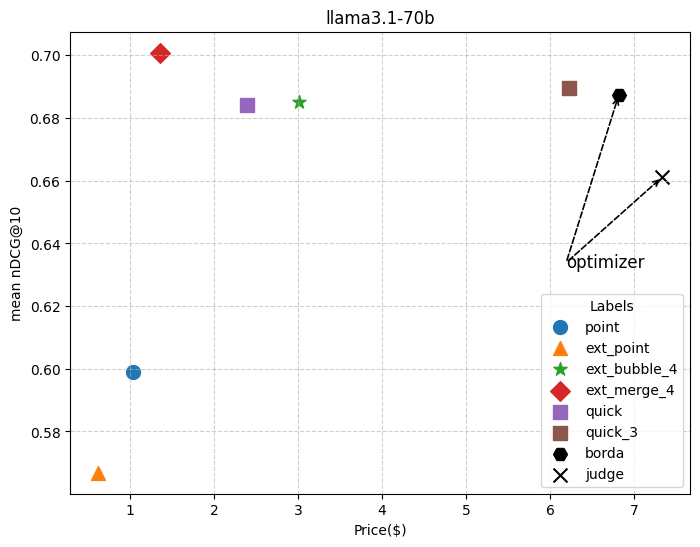

[0.7233107702119886, 0.6997421933477268]
opt_prices [81.38002, 90.2617]
borda 0.7233107702119886
judge 0.6997421933477268
-----optimal--------
best choice ['ext_merge_4', 'ext_merge_4,quick_3', 'ext_bubble_4,quick_3', 'ext_bubble_4,ext_merge_4,quick,quick_3', 'quick,quick_3', 'quick', 'ext_point', 'ext_merge_4', 'ext_merge_4', 'ext_merge_4', 'quick', 'ext_merge_4', ',point,ext_point,ext_bubble_4,ext_merge_4,quick,quick_3', 'ext_bubble_4', 'ext_bubble_4', 'quick', 'ext_bubble_4', 'ext_point', 'quick,quick_3', 'quick_3', 'ext_merge_4', 'ext_bubble_4', 'ext_bubble_4', 'quick_3', 'quick_3', 'ext_bubble_4,quick,quick_3', 'ext_bubble_4', 'ext_point,ext_merge_4,quick_3', ',point,quick,quick_3', 'quick_3', 'ext_bubble_4,ext_merge_4,quick,quick_3', 'quick_3', 'ext_merge_4', 'ext_bubble_4', 'ext_point', ',point', 'quick_3', 'quick_3', 'quick_3', 'quick,quick_3', 'quick_3', 'quick_3', 'ext_bubble_4,ext_merge_4,quick,quick_3', 'quick', ',point,ext_point,ext_bubble_4,ext_merge_4,quick,quick_3', 'ex

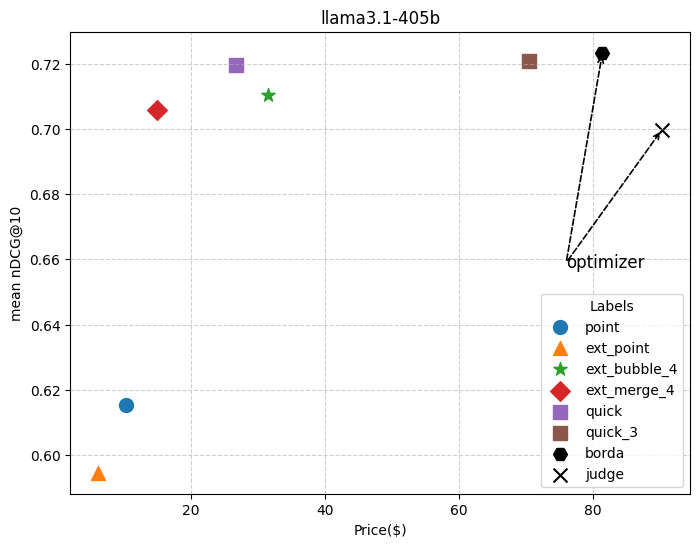

In [21]:
from scipy.optimize import curve_fit

for modelname in results.keys():
    if 'mistral' in modelname:
        continue

    alg2marker = {
        'point': 'o',
        'ext_point': '^',
        'quick': 's',
        'ext_bubble': '*',
        'ext_merge': 'D',
        'borda': 'H',
        'judge': 'x',
        'oracle': 'P', 
    }
    
    kendalltau = results[modelname]['acc']
    tokens = results[modelname]['token']
    prices = results[modelname]['price']
    dot_labels = results[modelname]['alg']
    markers = []
    for alg in dot_labels:
        if alg[-1].isdigit():
            alg = '_'.join(alg.split('_')[:-1])
        markers.append(alg2marker[alg])


    opt_acc = optimizer_results[modelname]['acc']
    print(opt_acc)
    opt_prices = optimizer_results[modelname]['price']
    print('opt_prices', opt_prices)
    opt_algs = optimizer_results[modelname]['alg']
    opt_algs = [alg.split(',')[0] for alg in opt_algs]
    for i in range(len(opt_algs)):
        if opt_algs[i] == 'llm_judge':
            opt_algs[i] = 'judge'
        elif opt_algs[i] == 'ideal':
            opt_algs[i] = 'oracle'
        print(opt_algs[i], opt_acc[i])
            
    query_acc = results[modelname]['query_acc']
    ideal_acc = query_acc[0][:]
    assert len(ideal_acc) == 54
    ideal_algs = [''] * len(ideal_acc)
    
    for alg, arr in zip(dot_labels, query_acc):
        assert len(arr) == 54, print(arr)
        for i in range(len(ideal_acc)):
            if arr[i] > ideal_acc[i]:
                ideal_acc[i] = arr[i]
                ideal_algs[i] = alg
            elif arr[i] == ideal_acc[i]:
                ideal_algs[i] += ',' + alg
                
    print('-----optimal--------')
    print('best choice', ideal_algs, ideal_acc)
    print('best choice mean ndcg@10', sum(ideal_acc)/len(ideal_acc) )
    print('------------------')

    for opt_alg, opt_query_acc in zip(optimizer_results[modelname]['query_alg'], optimizer_results[modelname]['query_acc']):
        print(opt_alg, opt_query_acc)
    
    # Create scatter plot
    plt.figure(figsize=(8, 6))

    print('acc, and label: ', kendalltau, dot_labels,)
    for x, y, label, m in zip(prices, kendalltau, dot_labels, markers):
        plt.scatter(x, y, s=100, marker=m, label=label)


    for x, y, label in zip(opt_prices, opt_acc, opt_algs):
        m = alg2marker[label]
        print('x, y', x, y)
        plt.scatter(x, y, s=100, marker=m, label=label, color='k')

    text_x, text_y = 0.8, 0.5
    ax = plt.gca()

    y0 = sum(ideal_acc) / len(ideal_acc)
    # plt.axhline(y=y0, linestyle='--')
    
    for x, y in zip(opt_prices, opt_acc):
        ax.annotate(
            "",
            xy=(x, y),               # data coordinates (point)
            xycoords="data",
            xytext=(text_x, text_y), # axes fraction coordinates (label position)
            textcoords=ax.transAxes,
            arrowprops=dict(
                arrowstyle="->",
                lw=1.2,
                linestyle="--",
                color = 'k'
            ),
        )
    
    ax.text(
        text_x, text_y,
        "optimizer",
        transform=ax.transAxes,   # <-- IMPORTANT
        fontsize=12,
        ha="left",
        va="center"
    )

    

    plt.legend(title="Labels")

    # Axis labels and title
    plt.xlabel("Price($)")
    plt.ylabel("mean nDCG@10")
    plt.title(f"{modelname}")
    yticks = plt.yticks()[0]            # get current tick locations
    # plt.yticks(list(yticks) + [math.floor(y0 * 100) / 100.0])     # add the new tick 
    
    # Show grid and plot
    plt.grid(True, linestyle='--', alpha=0.6)
    # plt.savefig(f'{modelname}DL20Unlimited.png')
    # plt.savefig(f'{modelname}DL20limited.png')
    plt.show()


['borda', 'judge']
0 point
1 ext_point
2 ext_bubble_4
3 ext_merge_4
4 quick
5 quick_3
6 borda
7 judge


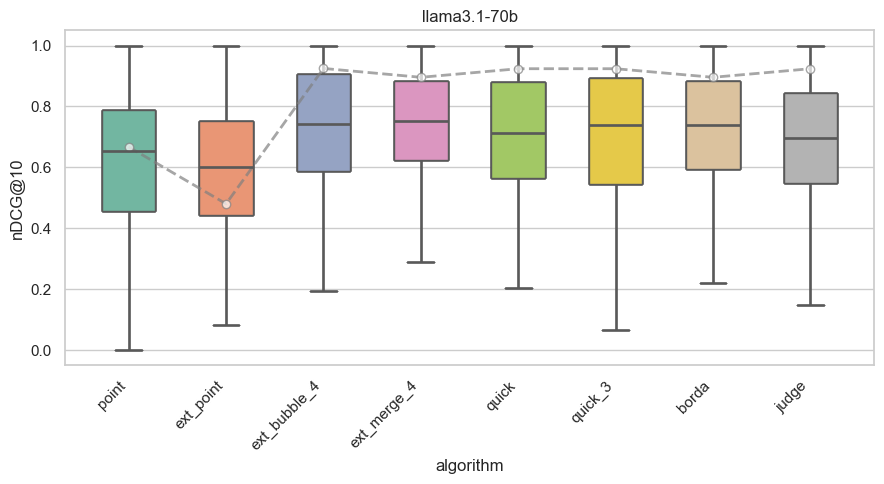

['borda', 'judge']
0 point
1 ext_point
2 ext_bubble_4
3 ext_merge_4
4 quick
5 quick_3
6 borda
7 judge


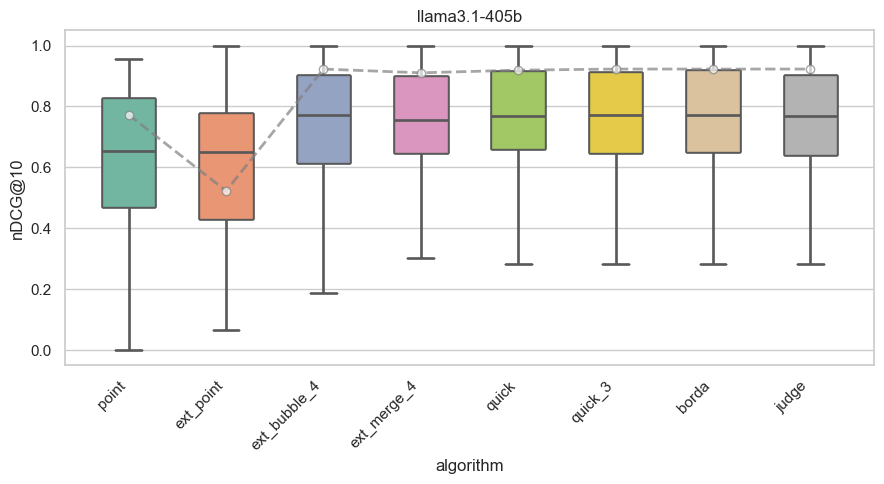

In [22]:
for model in results.keys():
    algs = results[model]['alg'][:]
    data = results[model]['query_acc'][:]

    ideal_acc = data[0][:]
    for alg_acc in data:
        for i, acc in enumerate(alg_acc):
            ideal_acc[i] = max(ideal_acc[i], acc)
    

    # ----------add optimizer result-----
    opt_query_acc = optimizer_results[model]['query_acc']
    opt_algs = optimizer_results[model]['alg']
    opt_algs = [alg.split(',')[0] for alg in opt_algs]
    for i in range(len(opt_algs)):
        if opt_algs[i] == 'llm_judge':
            opt_algs[i] = 'judge'
        elif opt_algs[i] == 'ideal':
            opt_algs[i] = 'oracle'
    
    print(opt_algs)
    algs += opt_algs
    data += opt_query_acc


    # algs.append('optimal')
    # data.append(ideal_acc)


    df = pd.DataFrame({
        "algorithm": sum([[alg] * len(accs) for alg, accs in zip(algs, data)], []),
        "accuracy": sum(data, []),
        "run_idx": sum([list(range(len(accs))) for accs in data], [])
    })

    plt.figure(figsize=(9, 5))
    sns.set(style="whitegrid")

    

    # --- color palette ---
    palette = sns.color_palette("Set2", len(algs))
    color_map = dict(zip(algs, palette))

    # --- jitter width ---
    jitter = 0.12

    for i, alg in enumerate(algs):
        print(i ,alg)
        sub = df[df["algorithm"] == alg]

        x_center = i
        x_jittered = x_center + np.random.uniform(-jitter, jitter, size=len(sub))

        sns.boxplot(
            data=df,
            x="algorithm",
            y="accuracy",
            hue="algorithm",      # required when using palette
            order=algs,
            palette=palette,
            width=0.55,
            showfliers=False,
            dodge=False,          # so boxes don't shift
            legend=False          # because hue=algorithm is redundant
        )

    run1_points = []
    run_index = 2
    for i, alg in enumerate(algs):
        sub = df[(df["algorithm"] == alg) & (df["run_idx"] == run_index)]
        if len(sub) > 0:
            run1_points.append((i, sub["accuracy"].iloc[0]))
    
    # unpack x and y
    xs = [p[0] for p in run1_points]
    ys = [p[1] for p in run1_points]
    
    # draw connection line
    plt.plot(
        xs,
        ys,
        linewidth=2.0,
        color="gray",
        alpha=0.7,
        linestyle="--",
        marker="o",
        markersize=6,
        markerfacecolor="white",
        markeredgecolor="gray",
        zorder=2
    )

    # ---- cosmetics ----
    plt.xticks(range(len(algs)), algs, rotation=45, ha="right")
    plt.ylabel("nDCG@10")
    plt.title(f"{model}")
    plt.tight_layout()
    # plt.savefig(f'{model}DL20PointCloudUnlimited.png')
    # plt.savefig(f'{model}DL20PointCloudlimited.png')
    plt.show()